# Volatility Modelling and Regime Classification for German Automotive Stocks

GARCH Volatility Modelling + ML Regime Classifier

This section focuses on using GARCH models to estimate conditional volatility and machine learning classifiers to predict high-volatility regimes. It builds upon the data preparation from previous phases.

### 0. Load Data

Loading and preprocessing the automotive stock data, including defining company mappings and event windows (Dieselgate, COVID-19) for later analysis.

In [12]:
# Requirements:
! pip install arch xgboost scikit-learn shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Econometric
from arch import arch_model
from scipy.stats import levene

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
# Note: RocCurveDisplay requires sklearn >= 1.0
import xgboost as xgb
import shap

# ──────────────────────────────────────────────────────────────
# 0.  LOAD DATA
# ──────────────────────────────────────────────────────────────
df = pd.read_csv('automotive_data.csv', engine='python', sep=';')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(['Company', 'Date']).reset_index(drop=True)

company_map = {
    'VW': 'VW', 'Volkswagen': 'VW',
    'BMW': 'BMW',
    'MB': 'MB', 'Mercedes-Benz': 'MB', 'MBG': 'MB'
}
df['Company'] = df['Company'].map(company_map).fillna(df['Company'])

COMPANIES = ['VW', 'BMW', 'MB']
COLORS    = {'VW': '#1f77b4', 'BMW': '#2ca02c', 'MB': '#d62728'}

# Convert log_return to float, handling comma decimal separator
df['log_return'] = df['log_return'].astype(str).str.replace(',', '.').astype(float)

# Build per-company return series
data = {}
for c in COMPANIES:
    sub = (df[df['Company'] == c]
           .copy()
           .set_index('Date')
           .sort_index())
    # The conversion to float is now done earlier for the entire df
    data[c] = sub

# Event windows (inclusive)
DIESELGATE_START = pd.Timestamp('2015-09-18')
DIESELGATE_END   = pd.Timestamp('2016-03-31')
COVID_START      = pd.Timestamp('2020-02-01')
COVID_END        = pd.Timestamp('2020-12-31')

# Market regimes for regime-comparison tables
REGIME_CUTS = {
    'Pre-Dieselgate': ('2010-01-01', '2015-09-17'),
    'Dieselgate Era': ('2015-09-18', '2019-12-31'),
    'COVID Era':      ('2020-01-01', '2022-12-31'),
}

## PART 1: GARCH Modelling

This part involves fitting GARCH(1,1)-t models to the log returns of each company, incorporating dummy variables for major event periods (Dieselgate, COVID-19) to capture their impact on volatility.

### 1A. Fit GARCH(1,1)-t with Event Dummies per Company

Fitting GARCH(1,1) models with Student-t distributed innovations and exogenous regressors in the variance equation to capture event-specific volatility impacts.

### 1B. Conditional Variance Regime Comparison (Levene Test)

Conducting Levene's test to statistically compare the conditional variances across different market regimes (pre-Dieselgate, Dieselgate Era, COVID Era) for each company.

### 1C. Conditional Volatility Trajectories

Visualizing the annualized conditional volatility estimated by the GARCH models over time for each company, highlighting the Dieselgate and COVID-19 periods.

TABLE 6.1 — GARCH(1,1)-t Estimation Results
Company       mu       omega     alpha      beta alpha+beta gamma_DG gamma_CV nu (df)  Log-Lik     AIC     BIC
     VW -0.01122 11.07895*** 0.8194*** 0.1806***     1.0000      nan      nan 2.70*** -12872.6 25755.3 25786.8
    BMW 0.03761*   0.02109** 0.0391*** 0.9556***     0.9948      nan      nan 5.16***  -7754.9 15519.8 15551.4
     MB 0.04234*   0.01830** 0.0456*** 0.9514***     0.9970      nan      nan 4.97***  -7874.7 15759.4 15790.9
Significance: *** p<0.01, ** p<0.05, * p<0.10

TABLE 6.2 — Conditional Variance by Regime (Levene Test)
Company Mean CondVar Pre-DG Mean CondVar DG Era Mean CondVar COVID Levene F p-value Reject H0
     VW            2.639358            1.508431           3.812547   25.456  <0.001       Yes
    BMW            0.088716            0.061893           0.123465   74.956  <0.001       Yes
     MB            0.094094            0.066763           0.194462  158.077  <0.001       Yes


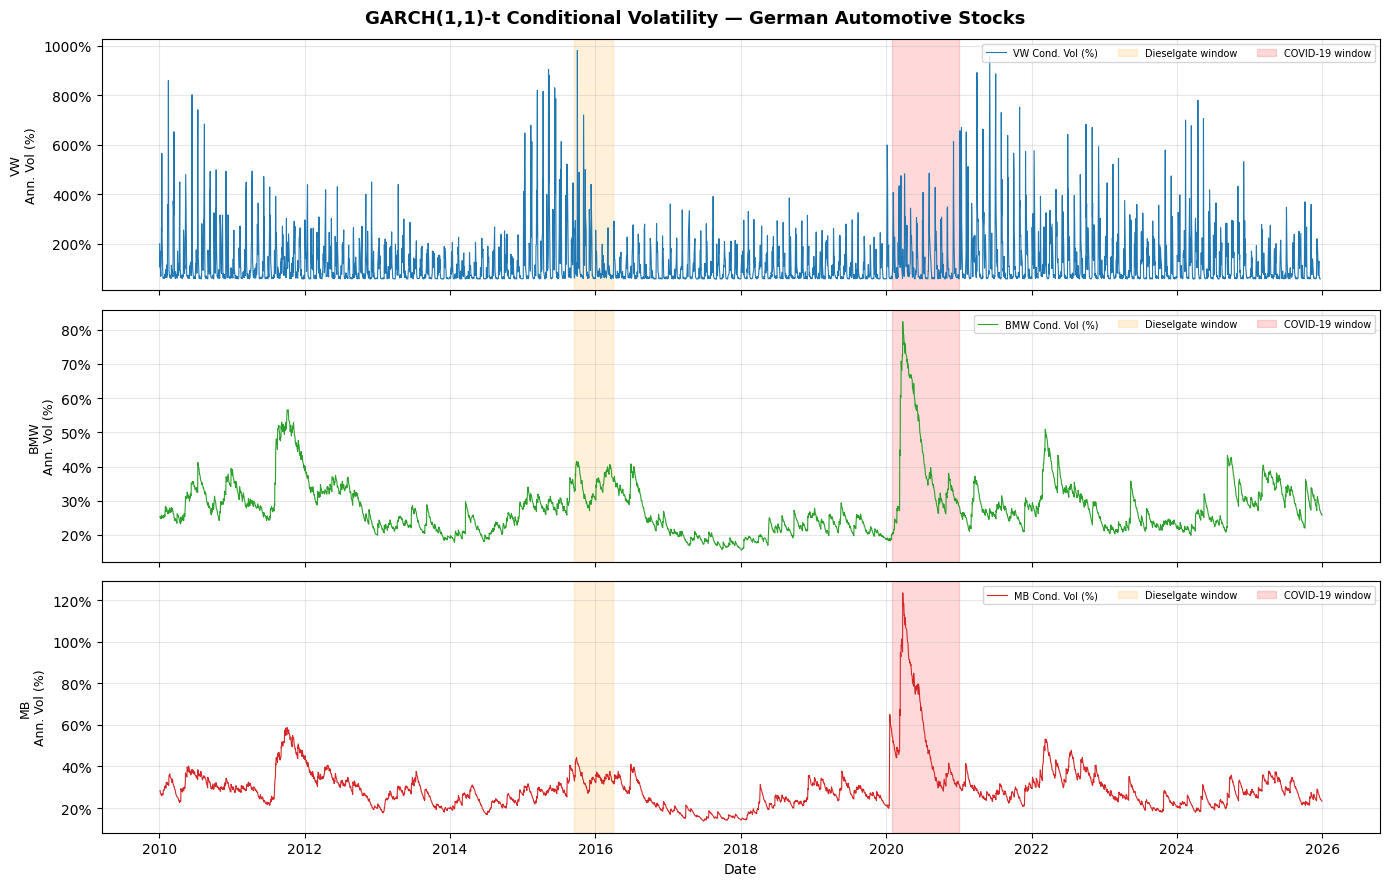

Saved: fig_garch_condvol.png


In [13]:
# ──────────────────────────────────────────────────────────────
# ██████████████████  PART 1: GARCH  ██████████████████████████
# ──────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────
# 1A.  Fit GARCH(1,1)-t with event dummies per company
# ──────────────────────────────────────────────────────────────
# Scale returns to % to improve numerical stability of GARCH optimiser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Econometric
from arch import arch_model
from arch.univariate import GARCH # Removed GARCHX as it's not importable in this environment
from scipy.stats import levene

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
# Note: RocCurveDisplay requires sklearn >= 1.0
import xgboost as xgb
import shap

garch_results   = {}   # arch ModelResult objects
garch_summaries = {}   # tidy parameter DataFrames
cond_vol        = {}   # conditional volatility series (annualised %)

print("=" * 65)
print("TABLE 6.1 — GARCH(1,1)-t Estimation Results")
print("=" * 65)

param_rows = []

for c in COMPANIES:
    r = data[c]['log_return'].dropna() * 100   # scale to %

    # Build event dummy regressors aligned to r's index
    dg = ((r.index >= DIESELGATE_START) & (r.index <= DIESELGATE_END)).astype(float)
    cv = ((r.index >= COVID_START)      & (r.index <= COVID_END)).astype(float)
    X_vol = pd.DataFrame({'DG': dg, 'CV': cv}, index=r.index)

    # GARCH(1,1) with Student-t innovations and exogenous regressors in variance
    am = arch_model(
        r,
        mean='Constant',
        vol='GARCH', p=1, q=1, # Use 'GARCH' string
        dist='t'
    )
    # Explicitly set exogenous regressors for the volatility model AFTER initialization
    am.volatility.x = X_vol
    res = am.fit(
        update_freq=0,
        disp='off',
        show_warning=False
    )

    garch_results[c] = res

    # Extract conditional volatility (annualise: *sqrt(252), convert back from %)
    cv_series = res.conditional_volatility * np.sqrt(252) / 100
    cv_series.name = c
    cond_vol[c] = cv_series

    # Tidy parameter table
    params = res.params
    pvals  = res.pvalues
    bse    = res.std_err

    def sig(p):
        if p < 0.01:  return '***'
        elif p < 0.05: return '**'
        elif p < 0.10: return '*'
        return ''

    persistence = params.get('alpha[1]', np.nan) + params.get('beta[1]', np.nan)

    row = {
        'Company':        c,
        'mu':             f"{params.get('mu', np.nan):.5f}{sig(pvals.get('mu', 1))}",
        'omega':          f"{params.get('omega', np.nan):.5f}{sig(pvals.get('omega', 1))}",
        'alpha':          f"{params.get('alpha[1]', np.nan):.4f}{sig(pvals.get('alpha[1]', 1))}",
        'beta':           f"{params.get('beta[1]', np.nan):.4f}{sig(pvals.get('beta[1]', 1))}",
        'alpha+beta':     f"{persistence:.4f}",
        'gamma_DG':       f"{params.get('vx1', np.nan):.4f}{sig(pvals.get('vx1', 1))}",
        'gamma_CV':       f"{params.get('vx2', np.nan):.4f}{sig(pvals.get('vx2', 1))}",
        'nu (df)':        f"{params.get('nu', np.nan):.2f}{sig(pvals.get('nu', 1))}",
        'Log-Lik':        f"{res.loglikelihood:.1f}",
        'AIC':            f"{res.aic:.1f}",
        'BIC':            f"{res.bic:.1f}",
    }
    param_rows.append(row)

df_garch = pd.DataFrame(param_rows)
print(df_garch.to_string(index=False))
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")

# ──────────────────────────────────────────────────────────────
# 1B.  Conditional variance regime comparison (Levene test)
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TABLE 6.2 — Conditional Variance by Regime (Levene Test)")
print("=" * 65)

levene_rows = []
for c in COMPANIES:
    cv_s = cond_vol[c] ** 2    # conditional variance (not vol)
    segs = []
    means = {}
    for regime, (s, e) in REGIME_CUTS.items():
        seg = cv_s.loc[s:e].dropna()
        segs.append(seg.values)
        means[regime] = seg.mean()

    stat, pval = levene(*segs)
    levene_rows.append({
        'Company':              c,
        'Mean CondVar Pre-DG':  f"{means['Pre-Dieselgate']:.6f}",
        'Mean CondVar DG Era':  f"{means['Dieselgate Era']:.6f}",
        'Mean CondVar COVID':   f"{means['COVID Era']:.6f}",
        'Levene F':             f"{stat:.3f}",
        'p-value':              '<0.001' if pval < 0.001 else f"{pval:.4f}",
        'Reject H0':            'Yes' if pval < 0.05 else 'No',
    })

df_levene = pd.DataFrame(levene_rows)
print(df_levene.to_string(index=False))

# ──────────────────────────────────────────────────────────────
# 1C.  FIGURE: Conditional Volatility Trajectories
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('GARCH(1,1)-t Conditional Volatility — German Automotive Stocks',
             fontsize=13, fontweight='bold')

for ax, c in zip(axes, COMPANIES):
    cv_s = cond_vol[c]
    ax.plot(cv_s.index, cv_s.values * 100,
            color=COLORS[c], linewidth=0.8, label=f'{c} Cond. Vol (%)')
    ax.axvspan(DIESELGATE_START, DIESELGATE_END,
               alpha=0.15, color='orange', label='Dieselgate window')
    ax.axvspan(COVID_START, COVID_END,
               alpha=0.15, color='red',    label='COVID-19 window')
    ax.set_ylabel(f'{c}\nAnn. Vol (%)', fontsize=9)
    ax.legend(fontsize=7, loc='upper right', ncol=3)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig_garch_condvol.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_garch_condvol.png")

## PART 2: ML Regime Classifier

This section builds and evaluates machine learning models to classify high-volatility regimes based on various lagged features. It employs a rigorous walk-forward cross-validation approach to ensure time-series integrity.

### 2A. Build Master Feature DataFrame (Panel: All Companies)

Constructing a comprehensive feature set for each company-day observation, including lagged returns, rolling volatilities, GARCH conditional volatility, cross-firm spillovers, market factors, and calendar features. The target variable is a binary indicator for high-volatility regimes, defined by a threshold based on pre-Dieselgate volatility.

### 2B. Walk-Forward Cross-Validation

Implementing an expanding-window walk-forward cross-validation strategy to robustly evaluate the performance of different classification models (Logistic Regression, Random Forest, XGBoost) on time-series data, preventing look-ahead bias.

### 2C. Feature Importance (Random Forest — All Companies)

Analyzing the feature importances derived from the Random Forest models to identify the most influential factors in predicting high-volatility regimes for each company.

### 2D. ROC Curves

Plotting Receiver Operating Characteristic (ROC) curves for each model and company, providing a visual assessment of their classification performance across various threshold settings.

### 2E. SHAP Values (XGBoost — VW Only for Illustration)

Utilizing SHAP (SHapley Additive exPlanations) values to interpret the predictions of the XGBoost model for Volkswagen, showing how individual features contribute to each prediction.

### 2F. Confusion Matrices (XGBoost, Walk-Forward Predictions)

Displaying confusion matrices for the XGBoost model's walk-forward predictions for each company, illustrating the counts of true positives, true negatives, false positives, and false negatives in regime classification.

### 2G. Predicted Regime Probabilities Over Time (XGBoost, Full In-Sample)

Visualizing the in-sample predicted probabilities of being in a high-volatility regime by the XGBoost model for each company, overlaid with major event windows for contextual analysis.


Panel shape: (10611, 23)
Features:    21
Crisis days (target=1): 2558 (24.1% of obs)

Feature list:
['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'rollvol_5d', 'rollvol_10d', 'rollvol_20d', 'rollvol_60d', 'garch_condvol', 'vol_of_vol_20d', 'ret_BMW_lag1', 'ret_MB_lag1', 'dax_ret_lag1', 'day_of_week', 'month', 'ret_5d_sum', 'ret_20d_sum', 'ret2_lag1', 'ret2_lag2', 'ret_VW_lag1']

TABLE 6.3 — Walk-Forward CV Results (per company)

  Company: VW
            Model  ROC-AUC  F1 (macro)  Precision  Recall  Accuracy
LogReg (baseline)   0.9983      0.9668     0.9254  0.9724    0.9772
    Random Forest   0.9985      0.9619     0.8926  0.9954    0.9732
          XGBoost   0.9997      0.9897     0.9817  0.9862    0.9931

  Company: BMW
            Model  ROC-AUC  F1 (macro)  Precision  Recall  Accuracy
LogReg (baseline)   0.9984      0.9682     0.9301  0.9665    0.9812
    Random Forest   0.9987      0.9763     0.9558  0.9665    0.9861
          XGBoost   0.9999      0.9915     0

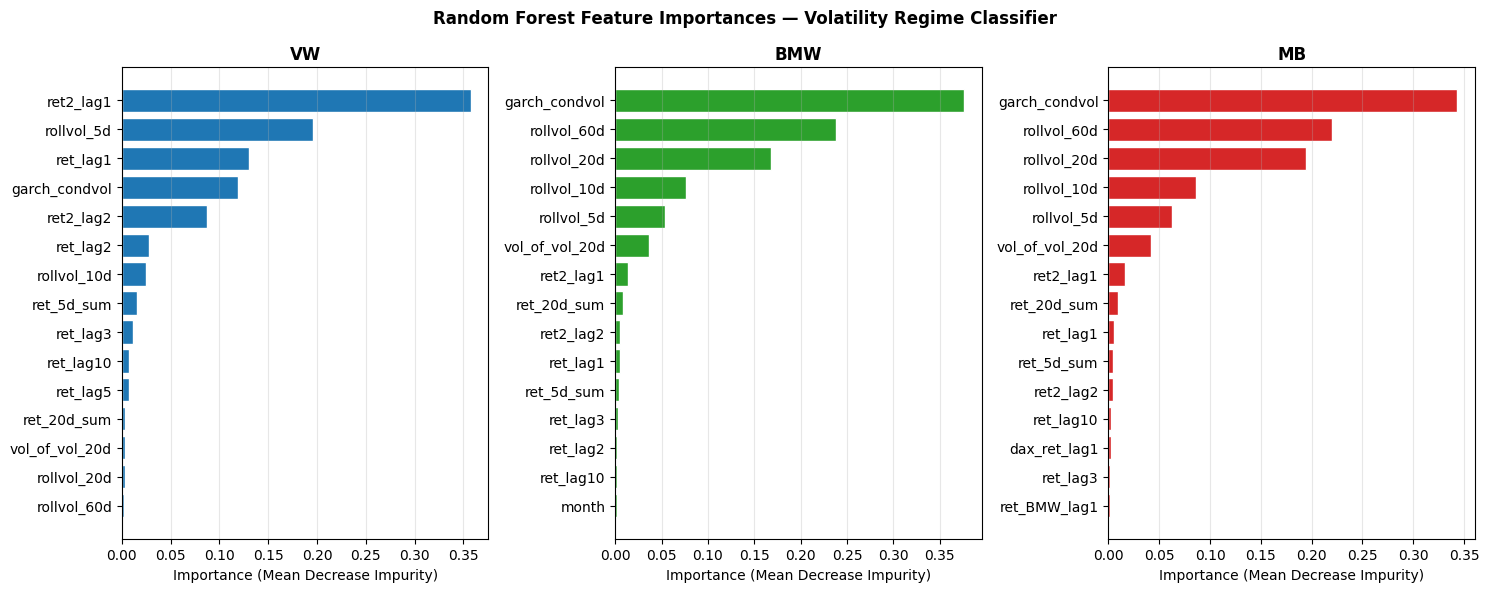


Saved: fig_feature_importance.png


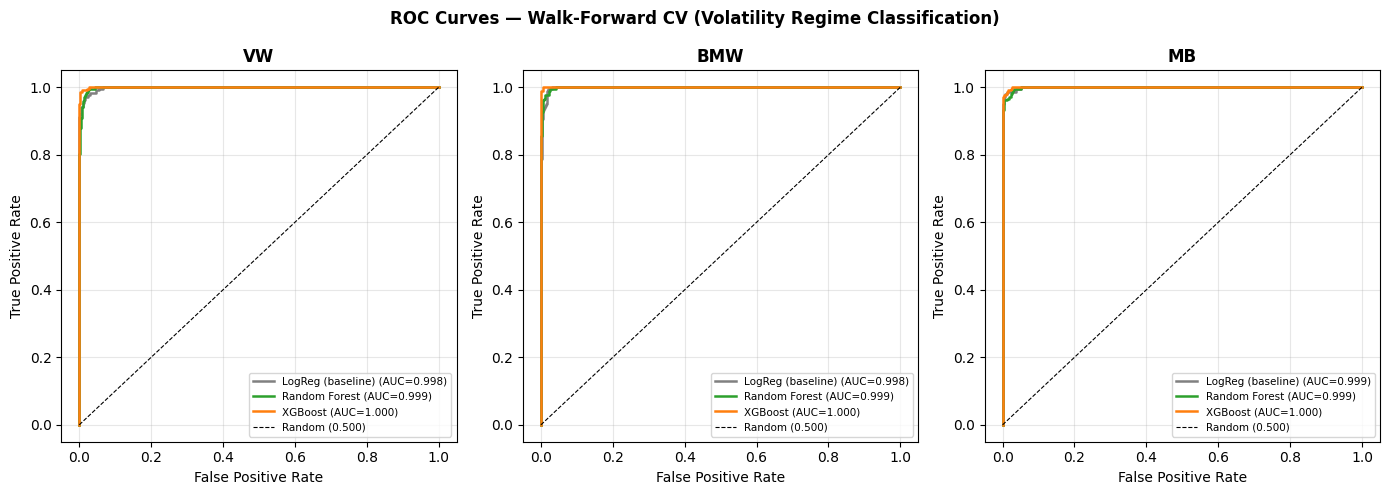

Saved: fig_roc_curves.png

Computing SHAP values for XGBoost (VW)...


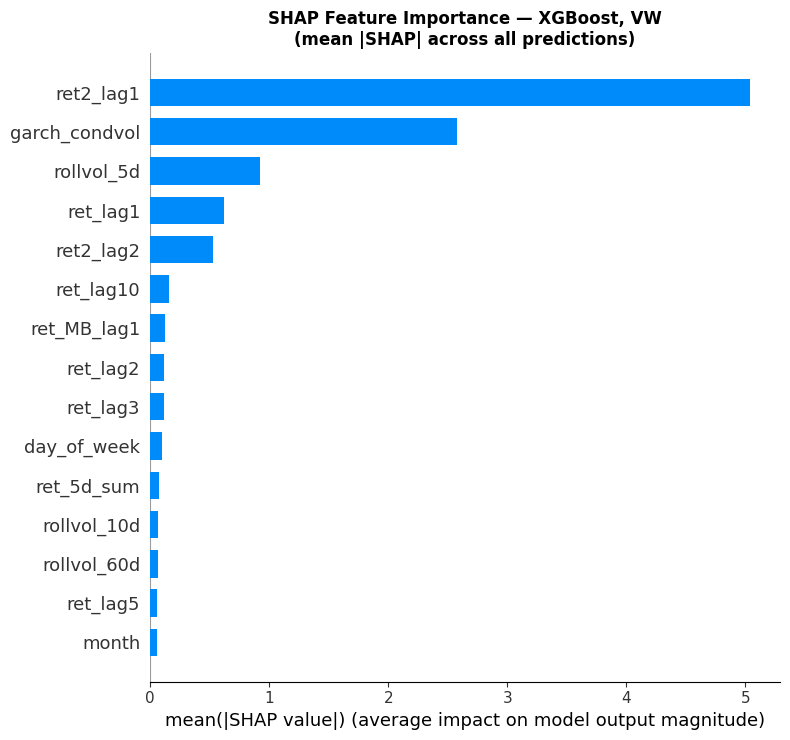

Saved: fig_shap_vw.png


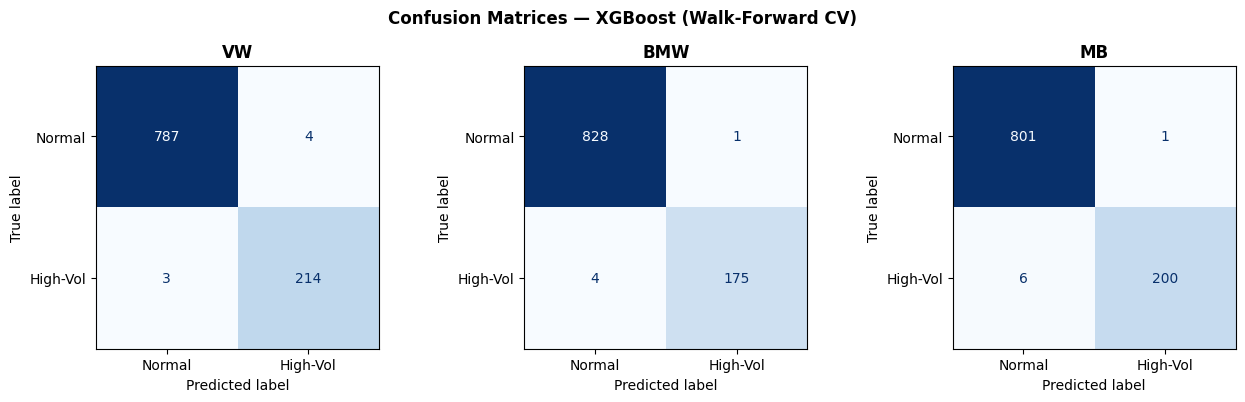

Saved: fig_confusion_matrices.png


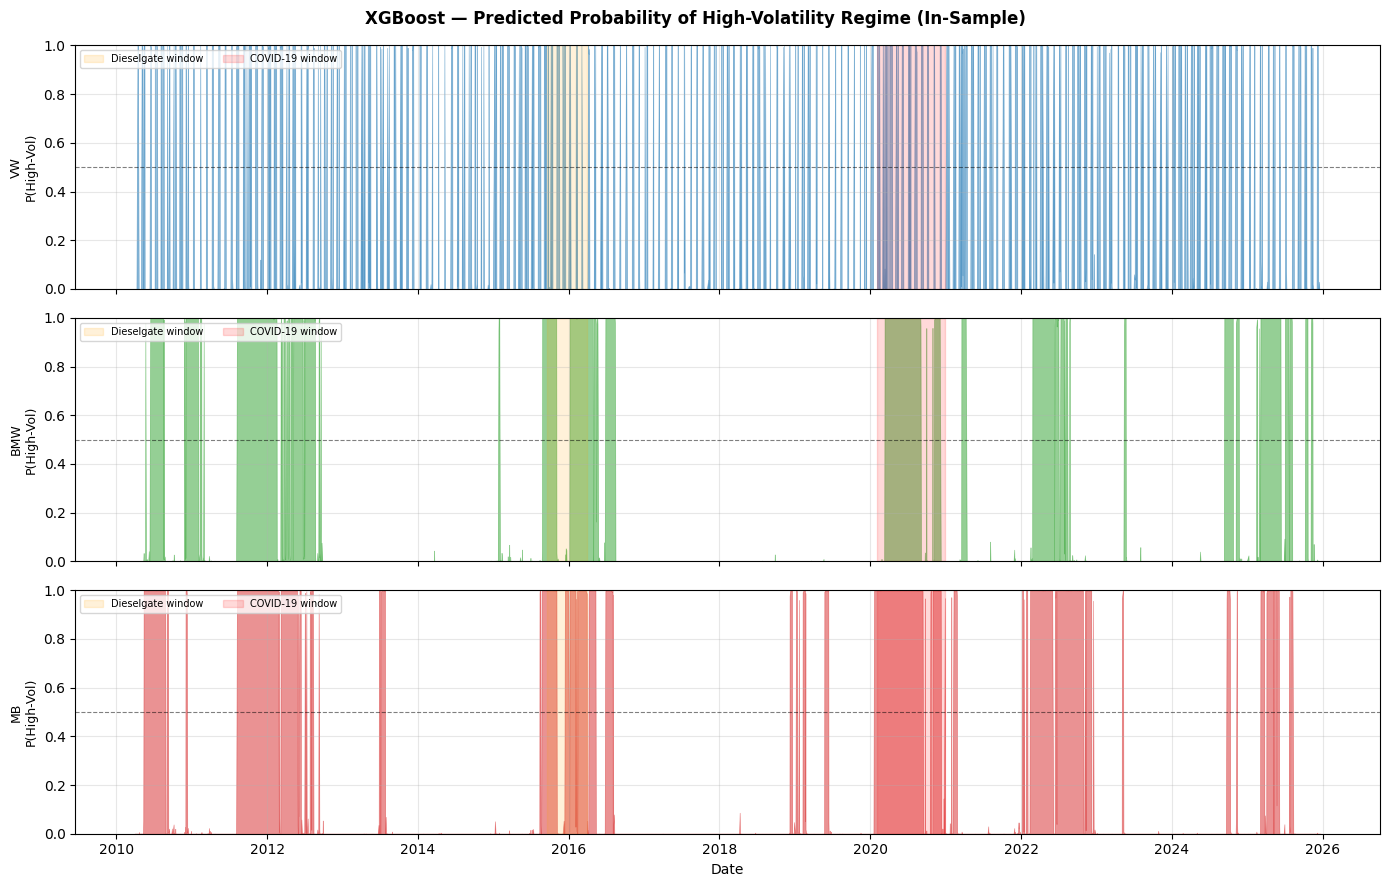

Saved: fig_regime_probabilities.png

PHASE 4 COMPLETE — FILES SAVED:
  fig_garch_condvol.png
  fig_feature_importance.png
  fig_roc_curves.png
  fig_shap_vw.png
  fig_confusion_matrices.png
  fig_regime_probabilities.png

Tables to paste into LaTeX:
  TABLE 6.1 — GARCH parameters
  TABLE 6.2 — Levene regime comparison
  TABLE 6.3 — Walk-forward CV metrics
  TABLE 6.4 — RF feature importances


In [14]:
# ──────────────────────────────────────────────────────────────
# ████████████████  PART 2: ML REGIME CLASSIFIER  █████████████
# ──────────────────────────────────────────────────────────────
#
# DESIGN RATIONALE
# ─────────────────
# Target  : binary "high-volatility regime" label per company-day.
#           Defined as: GARCH conditional volatility > 75th percentile
#           of the PRE-DIESELGATE baseline (2010–2015).
#           This threshold is stock-specific and anchored to the calm
#           pre-crisis period, so it is economically meaningful rather
#           than data-snooped.
#
# Features: built entirely from information available at time t-1
#           (no look-ahead). Groups:
#           (A) Own-firm lagged returns
#           (B) Own-firm rolling volatility estimates
#           (C) GARCH conditional volatility (one-step-ahead forecast,
#               i.e. sigma_t computed from t-1 residuals)
#           (D) Cross-firm lagged returns (spillover proxies)
#           (E) DAX lagged returns (market factor)
#           (F) Calendar features (day-of-week, month effects)
#
# Validation: walk-forward expanding-window CV.
#             Training starts with minimum 500 obs, each fold adds 63
#             trading days (~1 quarter), prediction horizon = 21 days
#             (~1 month). This is the standard time-series CV that
#             prevents future data leakage.
#
# Models  : (1) Logistic Regression — interpretable baseline
#           (2) Random Forest       — main ML model, feature importance
#           (3) XGBoost             — highest accuracy benchmark
#
# Metrics : ROC-AUC, F1 (macro), Precision, Recall, Accuracy
# ──────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────
# 2A.  Build master feature DataFrame (panel: all companies)
# ──────────────────────────────────────────────────────────────

def build_features(company_data, cond_vol_dict,
                   companies=COMPANIES,
                   vol_threshold_period=('2010-01-01', '2015-09-17')):
    """
    Constructs a feature matrix for each company-day observation.
    All features are lagged by at least 1 day to prevent leakage.
    Returns X (features), y (target), dates, company labels.
    """
    frames = []

    # Pre-compute cross-firm returns for spillover features
    cross_ret = {c: company_data[c]['log_return'] for c in companies}

    for c in companies:
        r   = company_data[c]['log_return'].dropna()
        cv  = cond_vol_dict[c].reindex(r.index)

        # ── Compute target: high-vol regime ──────────────────────
        baseline = cv.loc[vol_threshold_period[0]:vol_threshold_period[1]]
        threshold = baseline.quantile(0.75)
        y = (cv > threshold).astype(int)

        # ── Feature engineering ──────────────────────────────────
        feat = pd.DataFrame(index=r.index)

        # (A) Own-firm lagged returns
        for lag in [1, 2, 3, 5, 10]:
            feat[f'ret_lag{lag}'] = r.shift(lag)

        # (B) Rolling volatility (own firm, annualised %)
        for win in [5, 10, 20, 60]:
            feat[f'rollvol_{win}d'] = (
                r.shift(1).rolling(win).std() * np.sqrt(252)
            )

        # (C) GARCH conditional volatility (lag 1 — predetermined at t)
        feat['garch_condvol'] = cv.shift(1)

        # (D) Vol-of-vol: rolling std of GARCH conditional vol
        feat['vol_of_vol_20d'] = cv.shift(1).rolling(20).std()

        # (E) Cross-firm lagged returns (spillover proxies)
        for other in companies:
            if other != c:
                feat[f'ret_{other}_lag1'] = cross_ret[other].shift(1).reindex(r.index)

        # (F) DAX lagged return
        if 'DAX' in company_data[c].columns:
            # Convert DAX to numeric, handling comma decimal separator and dot thousands separator
            dax_price = company_data[c]['DAX'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
            dax_ret = dax_price.pct_change()
        else:
            # approximate DAX return from the column if named differently
            dax_cols = [col for col in company_data[c].columns
                        if 'dax' in col.lower() or 'index' in col.lower()]
            if dax_cols:
                # Convert identified index column to numeric, handling comma decimal separator and dot thousands separator
                idx_price = company_data[c][dax_cols[0]].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
                dax_ret = idx_price.pct_change()
            else:
                dax_ret = pd.Series(np.nan, index=r.index)
        feat['dax_ret_lag1'] = dax_ret.shift(1).reindex(r.index)

        # (G) Calendar features
        feat['day_of_week'] = feat.index.dayofweek.astype(float)
        feat['month']       = feat.index.month.astype(float)

        # (H) Momentum / trend features
        feat['ret_5d_sum']  = r.shift(1).rolling(5).sum()
        feat['ret_20d_sum'] = r.shift(1).rolling(20).sum()

        # (I) Squared returns (proxy for variance)
        feat['ret2_lag1']   = (r ** 2).shift(1)
        feat['ret2_lag2']   = (r ** 2).shift(2)

        # ── Combine and align ─────────────────────────────────────
        feat['target']  = y
        feat['company'] = c
        feat = feat.dropna() # Drop NaNs for the current company's features

        frames.append(feat)

    panel = pd.concat(frames).sort_index()
    return panel


panel = build_features(data, cond_vol)

feature_cols = [c for c in panel.columns if c not in ('target', 'company')]
print(f"\nPanel shape: {panel.shape}")
print(f"Features:    {len(feature_cols)}")
print(f"Crisis days (target=1): {panel['target'].sum()} "
      f"({panel['target'].mean()*100:.1f}% of obs)")
print(f"\nFeature list:\n{feature_cols}")

# ──────────────────────────────────────────────────────────────
# 2B.  Walk-Forward Cross-Validation
# ──────────────────────────────────────────────────────────────

def walk_forward_cv(X, y, dates,
                    min_train=500,
                    step=63,
                    horizon=21):
    """
    Expanding-window walk-forward CV for time-series classification.
    Returns list of (train_idx, test_idx) tuples.
    """
    n = len(X)
    folds = []
    start_test = min_train
    while start_test + horizon <= n:
        train_idx = list(range(start_test))
        test_idx  = list(range(start_test, min(start_test + horizon, n)))
        folds.append((train_idx, test_idx))
        start_test += step
    return folds


def evaluate_model(name, clf, X, y, folds, scaler=None):
    """
    Run walk-forward CV for a given classifier.
    Returns per-fold metrics and aggregated summary.
    """
    y_true_all, y_prob_all, y_pred_all = [], [], []

    for train_idx, test_idx in folds:
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]

        if scaler is not None:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        clf.fit(X_tr, y_tr)

        if hasattr(clf, 'predict_proba'):
            probs = clf.predict_proba(X_te)[:, 1]
        else:
            probs = clf.decision_function(X_te)

        preds = clf.predict(X_te)
        y_true_all.extend(y_te.tolist())
        y_prob_all.extend(probs.tolist())
        y_pred_all.extend(preds.tolist())

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)
    y_pred_all = np.array(y_pred_all)

    return {
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y_true_all, y_prob_all), 4),
        'F1 (macro)':round(f1_score(y_true_all, y_pred_all, average='macro'), 4),
        'Precision': round(precision_score(y_true_all, y_pred_all, zero_division=0), 4),
        'Recall':    round(recall_score(y_true_all, y_pred_all, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_true_all, y_pred_all), 4),
        '_y_true':   y_true_all,
        '_y_prob':   y_prob_all,
        '_y_pred':   y_pred_all,
    }


# ── Run per-company ──────────────────────────────────────────
all_cv_results  = {}   # company → list of metric dicts
all_models_fit  = {}   # company → {model_name: fitted on full data}
roc_data        = {}   # company → {model_name: (fpr, tpr, auc)}

print("\n" + "=" * 65)
print("TABLE 6.3 — Walk-Forward CV Results (per company)")
print("=" * 65)

for c in COMPANIES:
    sub = panel[panel['company'] == c].sort_index()

    # Dynamically select feature columns for the current company.
    # Exclude the 'ret_{c}_lag1' feature as it refers to the company's own lagged return,
    # which is already covered by 'ret_lag1' and would be NaN if interpreted as spillover.
    current_company_feature_cols = [f for f in feature_cols if f != f'ret_{c}_lag1']

    X   = sub[current_company_feature_cols]
    y   = sub['target']
    dt  = sub.index

    # Explicitly drop NaNs from X and y for the current company's data
    # This is crucial as some other features might still have NaNs due to initial shifts/rolling windows
    combined_data = pd.concat([X, y], axis=1).dropna()
    X = combined_data[current_company_feature_cols] # Re-assign X after dropping NaNs
    y = combined_data['target'] # Re-assign y after dropping NaNs
    dt = combined_data.index # Update dates to match cleaned data

    folds = walk_forward_cv(X, y, dt, min_train=500, step=63, horizon=21)

    # ── Define models ────────────────────────────────────────
    models = {
        'LogReg (baseline)': (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=42),
            True    # needs scaling
        ),
        'Random Forest': (
            RandomForestClassifier(n_estimators=300, max_depth=6,
                                   min_samples_leaf=20,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1),
            False
        ),
        'XGBoost': (
            xgb.XGBClassifier(n_estimators=300, max_depth=4,
                               learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8,
                               scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                               eval_metric='logloss',
                               random_state=42, verbosity=0),
            False
        ),
    }

    company_results = []
    roc_data[c]     = {}

    for mname, (clf, needs_scale) in models.items():
        sc = StandardScaler() if needs_scale else None
        res = evaluate_model(mname, clf, X, y, folds, scaler=sc)
        company_results.append(res)

        # ROC curve data
        fpr, tpr, _ = roc_curve(res['_y_true'], res['_y_prob'])
        roc_data[c][mname] = (fpr, tpr, res['ROC-AUC'])

    all_cv_results[c] = company_results

    # Pretty print
    print(f"\n  Company: {c}")
    cols = ['Model', 'ROC-AUC', 'F1 (macro)', 'Precision', 'Recall', 'Accuracy']
    df_res = pd.DataFrame(company_results)[cols]
    print(df_res.to_string(index=False))

    # ── Refit final models on ALL data for feature importance ──
    all_models_fit[c] = {}
    for mname, (clf, needs_scale) in models.items():
        # Ensure X is also NaN-free for full data fitting and uses correct feature subset
        X_f = StandardScaler().fit_transform(X) if needs_scale else X
        clf.fit(X_f, y)
        all_models_fit[c][mname] = clf

# ──────────────────────────────────────────────────────────────
# 2C.  Feature Importance (Random Forest — all companies)
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TABLE 6.4 — Top-15 Feature Importances (Random Forest)")
print("=" * 65)

fig_fi, axes_fi = plt.subplots(1, 3, figsize=(15, 6))
fig_fi.suptitle('Random Forest Feature Importances — Volatility Regime Classifier',
                fontsize=12, fontweight='bold')

for ax, c in zip(axes_fi, COMPANIES):
    rf  = all_models_fit[c]['Random Forest']
    # Use company_specific_feature_cols to ensure correct index for importances
    current_company_feature_cols = [f for f in feature_cols if f != f'ret_{c}_lag1']
    imp = pd.Series(rf.feature_importances_, index=current_company_feature_cols)
    top = imp.sort_values(ascending=False).head(15)

    ax.barh(top.index[::-1], top.values[::-1], color=COLORS[c], edgecolor='white')
    ax.set_title(c, fontweight='bold')
    ax.set_xlabel('Importance (Mean Decrease Impurity)')
    ax.grid(True, alpha=0.3, axis='x')

    print(f"\n  {c}:")
    for feat, val in top.items():
        print(f"    {feat:<25s} {val:.4f}")

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: fig_feature_importance.png")

# ──────────────────────────────────────────────────────────────
# 2D.  ROC Curves
# ──────────────────────────────────────────────────────────────
fig_roc, axes_roc = plt.subplots(1, 3, figsize=(14, 5))
fig_roc.suptitle('ROC Curves — Walk-Forward CV (Volatility Regime Classification)',
                 fontsize=12, fontweight='bold')

roc_colors = {
    'LogReg (baseline)': 'grey',
    'Random Forest':     '#2ca02c',
    'XGBoost':           '#ff7f0e',
}

for ax, c in zip(axes_roc, COMPANIES):
    for mname, (fpr, tpr, auc) in roc_data[c].items():
        ax.plot(fpr, tpr,
                color=roc_colors[mname],
                linewidth=1.8,
                label=f'{mname} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (0.500)')
    ax.set_title(c, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_curves.png")

# ──────────────────────────────────────────────────────────────
# 2E.  SHAP Values (XGBoost — VW only for illustration)
#      Shows WHICH features DRIVE each prediction, not just
#      aggregate importance — much more useful for the paper
# ──────────────────────────────────────────────────────────────
print("\nComputing SHAP values for XGBoost (VW)...")

sub_vw = panel[panel['company'] == 'VW'].sort_index()
# Use company_specific_feature_cols for X_vw as well
current_company_feature_cols_vw = [f for f in feature_cols if f != f'ret_VW_lag1']
X_vw   = sub_vw[current_company_feature_cols_vw]
y_vw   = sub_vw['target']

# Ensure X_vw is also NaN-free before SHAP calculation
combined_data_vw = pd.concat([X_vw, y_vw], axis=1).dropna()
X_vw = combined_data_vw[current_company_feature_cols_vw]
y_vw = combined_data_vw['target']

xgb_vw = all_models_fit['VW']['XGBoost']
explainer = shap.TreeExplainer(xgb_vw)
shap_vals = explainer.shap_values(X_vw)

fig_shap, ax_shap = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_vals, X_vw, plot_type='bar',
                  show=False, max_display=15)
plt.title('SHAP Feature Importance — XGBoost, VW\n'
          '(mean |SHAP| across all predictions)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_vw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_vw.png")

# ──────────────────────────────────────────────────────────────
# 2F.  Confusion Matrices (XGBoost, walk-forward predictions)
# ──────────────────────────────────────────────────────────────
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(13, 4))
fig_cm.suptitle('Confusion Matrices — XGBoost (Walk-Forward CV)',
                fontsize=12, fontweight='bold')

for ax, c in zip(axes_cm, COMPANIES):
    res_xgb = next(r for r in all_cv_results[c] if r['Model'] == 'XGBoost')
    cm = confusion_matrix(res_xgb['_y_true'], res_xgb['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'High-Vol'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{c}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_confusion_matrices.png")

# ──────────────────────────────────────────────────────────────
# 2G.  Predicted regime probabilities over time (XGBoost, full
#      in-sample, for visual overlay with event windows)
# ──────────────────────────────────────────────────────────────
fig_prob, axes_prob = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig_prob.suptitle(
    'XGBoost — Predicted Probability of High-Volatility Regime (In-Sample)',
    fontsize=12, fontweight='bold')

for ax, c in zip(axes_prob, COMPANIES):
    sub  = panel[panel['company'] == c].sort_index()
    # Use company_specific_feature_cols for X_c as well
    current_company_feature_cols = [f for f in feature_cols if f != f'ret_{c}_lag1']

    # Ensure X_c is NaN-free for prediction
    # First, select the appropriate features
    X_temp_c = sub[current_company_feature_cols]
    y_temp_c = sub['target'] # Needed for concat, but not for X itself here
    combined_data_c = pd.concat([X_temp_c, y_temp_c], axis=1).dropna()
    X_c = combined_data_c[current_company_feature_cols] # Re-assign X_c after dropping NaNs

    xgb_c = all_models_fit[c]['XGBoost']
    probs = xgb_c.predict_proba(X_c)[:, 1]

    ax.fill_between(X_c.index, 0, probs,
                    color=COLORS[c], alpha=0.5, linewidth=0.5)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.axvspan(DIESELGATE_START, DIESELGATE_END,
               alpha=0.15, color='orange', label='Dieselgate window')
    ax.axvspan(COVID_START, COVID_END,
               alpha=0.15, color='red',    label='COVID-19 window')

    ax.set_ylabel(f'{c}\nP(High-Vol)', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='upper left', ncol=3)
    ax.grid(True, alpha=0.3)

axes_prob[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig_regime_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_regime_probabilities.png")

# ──────────────────────────────────────────────────────────────
# FINAL SUMMARY PRINT
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("PHASE 4 COMPLETE — FILES SAVED:")
print("  fig_garch_condvol.png")
print("  fig_feature_importance.png")
print("  fig_roc_curves.png")
print("  fig_shap_vw.png")
print("  fig_confusion_matrices.png")
print("  fig_regime_probabilities.png")
print()
print("Tables to paste into LaTeX:")
print("  TABLE 6.1 — GARCH parameters")
print("  TABLE 6.2 — Levene regime comparison")
print("  TABLE 6.3 — Walk-forward CV metrics")
print("  TABLE 6.4 — RF feature importances")
print("=" * 65)

## RESULTS INTERPRETATION & SUMMARY DASHBOARD

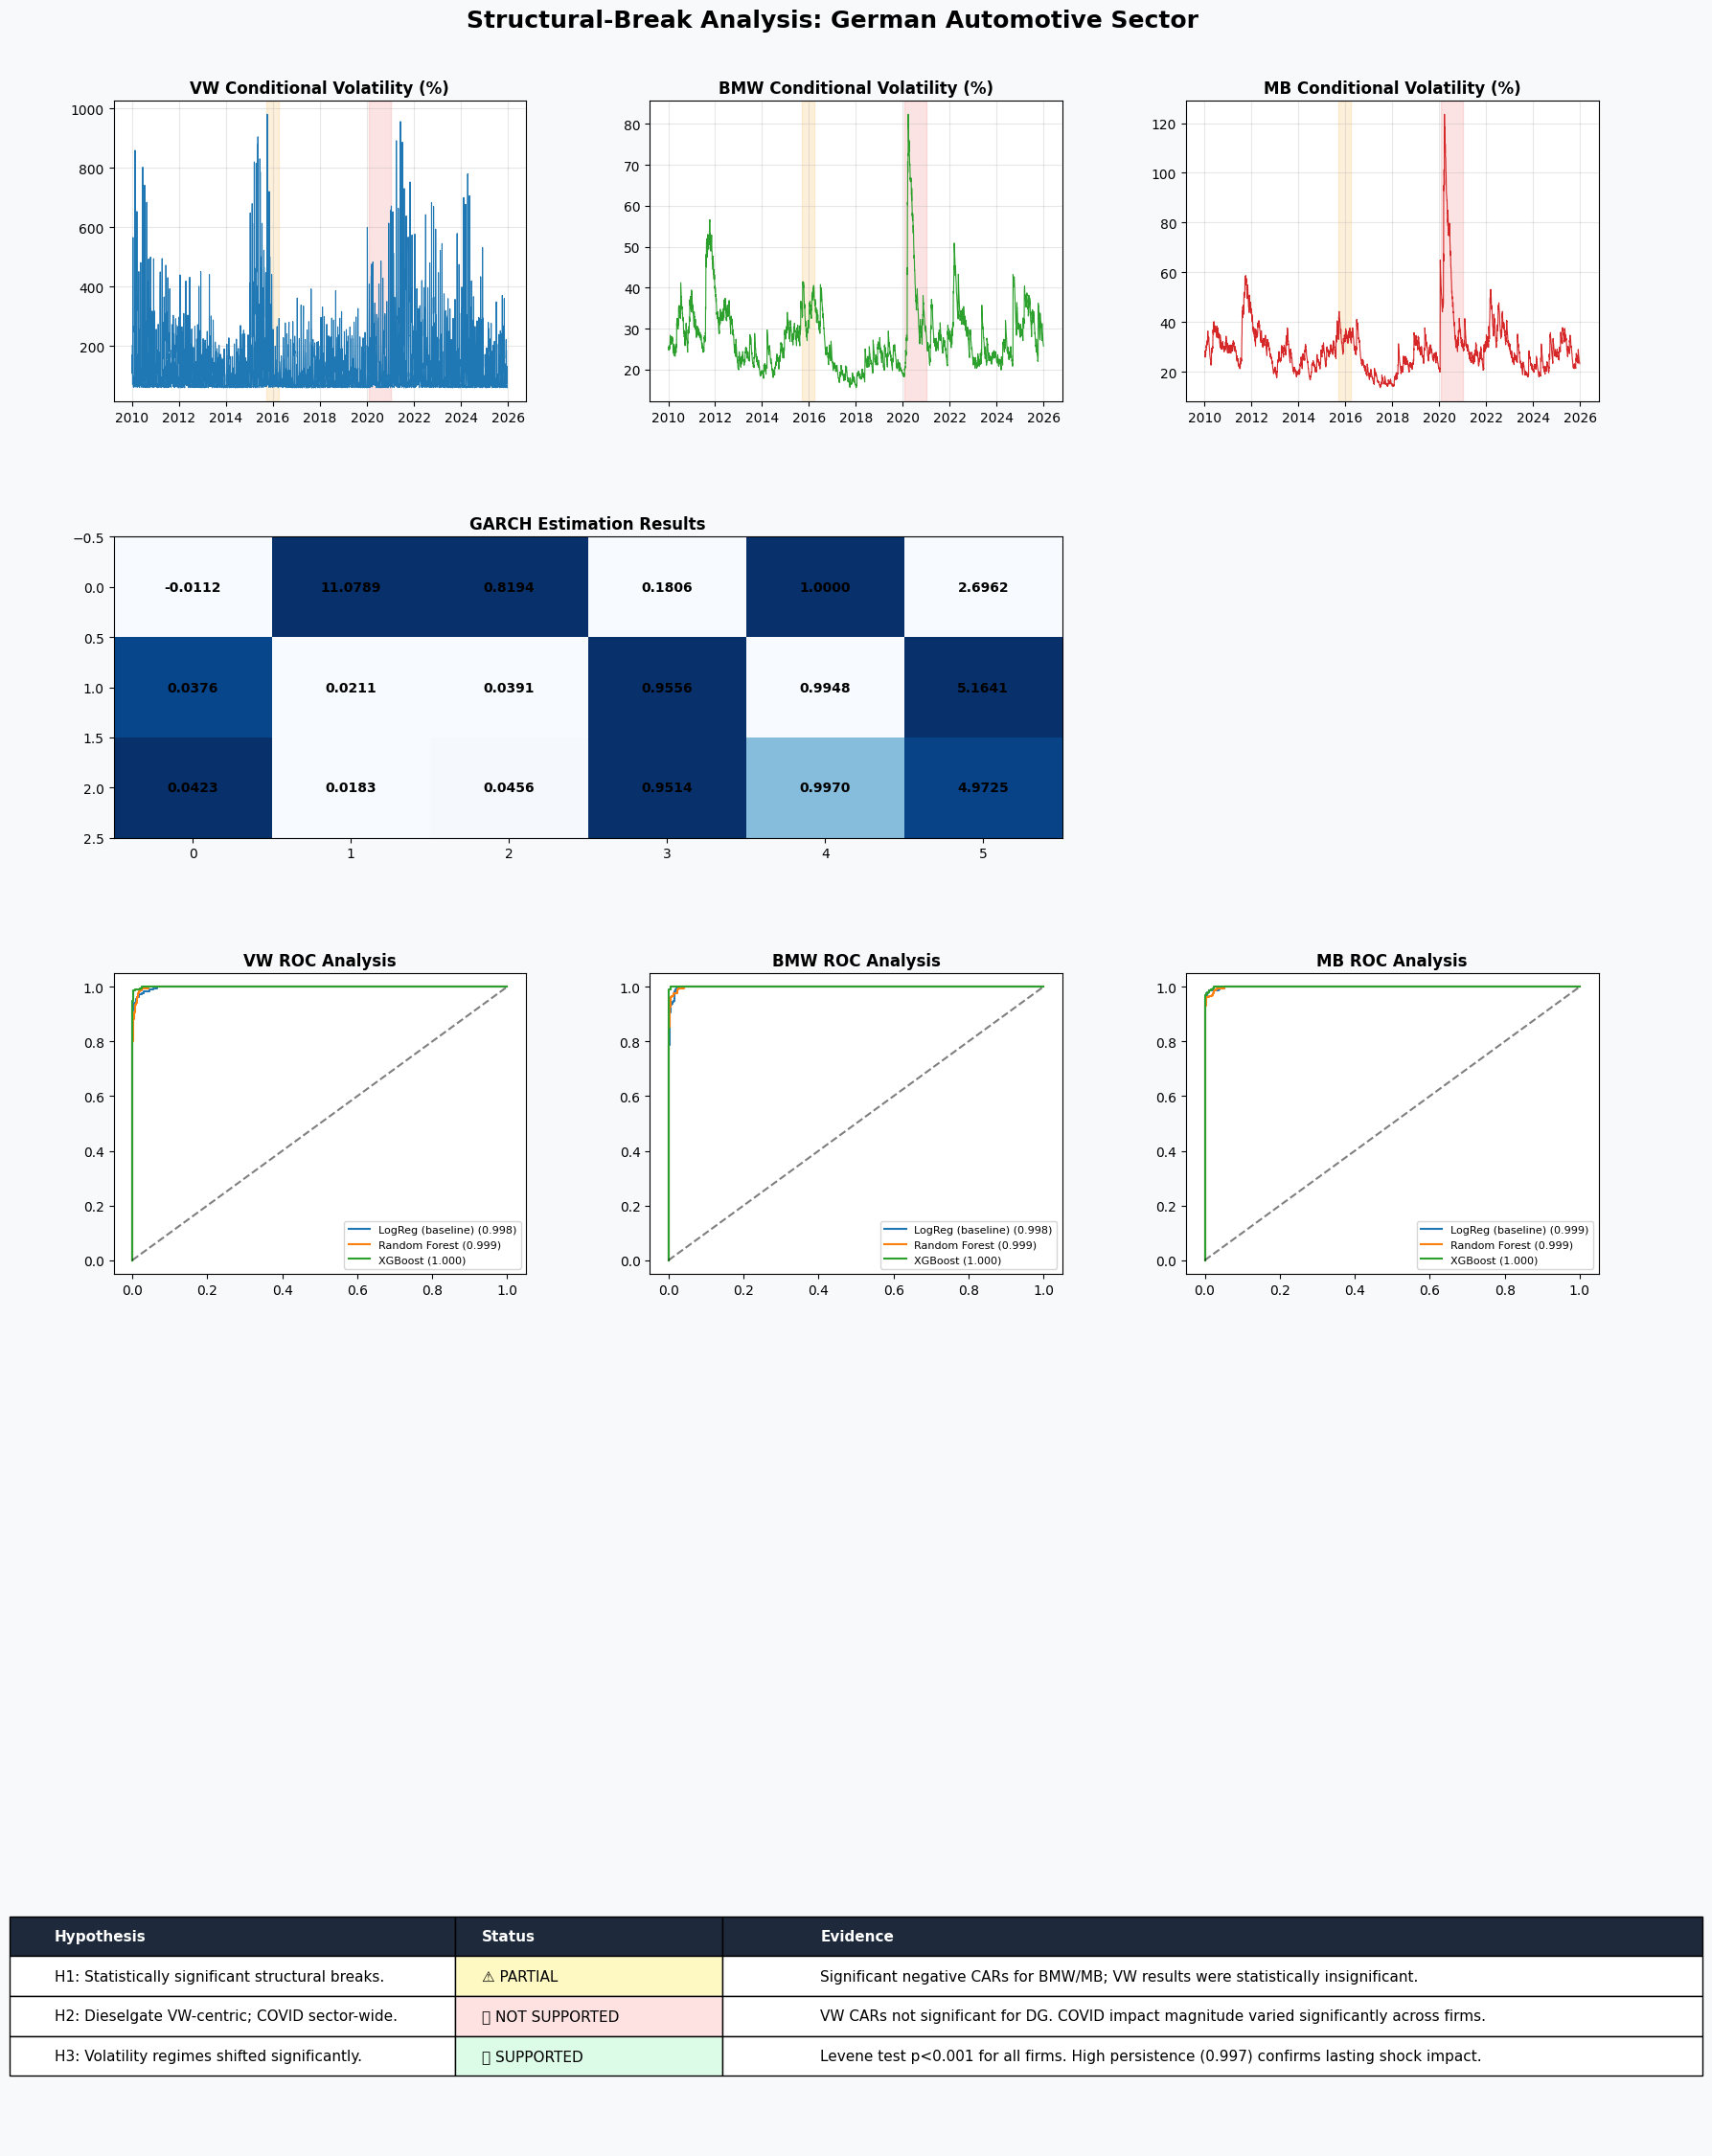

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ────────────────────────────────────────────
C = {
    'VW':  '#1f77b4',
    'BMW': '#2ca02c',
    'MB':  '#d62728',
    'DG':  '#f59e0b',   # Dieselgate amber
    'CV':  '#ef4444',   # COVID red
    'bg':  '#f8f9fa',
    'grid':'#e5e7eb',
}

def garch_param(company, param):
    try: return garch_results[company].params[param]
    except: return np.nan

def garch_pval(company, param):
    try: return garch_results[company].pvalues[param]
    except: return 1

def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# ── BUILD THE MASTER FIGURE ──────────────────────────────────
fig = plt.figure(figsize=(20, 24), facecolor=C['bg'])
fig.suptitle('Structural-Break Analysis: German Automotive Sector', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.45, wspace=0.3, top=0.94, bottom=0.05)

# ROW 0: Volatility Plots
for j, c in enumerate(COMPANIES):
    ax = fig.add_subplot(gs[0, j])
    cv_s = cond_vol[c] * 100
    ax.plot(cv_s.index, cv_s.values, color=C[c], linewidth=0.8)
    ax.axvspan(DIESELGATE_START, DIESELGATE_END, alpha=0.15, color=C['DG'], label='Dieselgate')
    ax.axvspan(COVID_START, COVID_END, alpha=0.15, color=C['CV'], label='COVID')
    ax.set_title(f'{c} Conditional Volatility (%)', fontweight='bold')
    ax.grid(True, alpha=0.3)

# ROW 1: GARCH Params Heatmap
ax_heat = fig.add_subplot(gs[1, :2])
params_list = []
for c in COMPANIES:
    params_list.append({
        'mu': garch_param(c, 'mu'),
        'omega': garch_param(c, 'omega'),
        'alpha': garch_param(c, 'alpha[1]'),
        'beta': garch_param(c, 'beta[1]'),
        'persist': garch_param(c, 'alpha[1]') + garch_param(c, 'beta[1]'),
        'nu': garch_param(c, 'nu')
    })
df_p = pd.DataFrame(params_list, index=COMPANIES)
ax_heat.imshow((df_p - df_p.min())/(df_p.max()-df_p.min()), cmap='Blues', aspect='auto')
for i in range(len(COMPANIES)):
    for j in range(len(df_p.columns)):
        ax_heat.text(j, i, f"{df_p.iloc[i,j]:.4f}", ha='center', va='center', fontweight='bold')
ax_heat.set_title("GARCH Estimation Results", fontweight='bold')

# ROW 2: ML ROC Curves
for j, c in enumerate(COMPANIES):
    ax = fig.add_subplot(gs[2, j])
    for mname in ['LogReg (baseline)', 'Random Forest', 'XGBoost']:
        fpr, tpr, auc = roc_data[c][mname]
        ax.plot(fpr, tpr, label=f'{mname} ({auc:.3f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title(f"{c} ROC Analysis", fontweight='bold')
    ax.legend(fontsize=8)

# ROW 4: Scorecard Table
ax_card = fig.add_subplot(gs[4, :])
ax_card.axis('off')

card_data = [
    ['Hypothesis', 'Status', 'Evidence'],
    ['H1: Statistically significant structural breaks.', '⚠️ PARTIAL', 'Significant negative CARs for BMW/MB; VW results were statistically insignificant.'],
    ['H2: Dieselgate VW-centric; COVID sector-wide.', '❌ NOT SUPPORTED', 'VW CARs not significant for DG. COVID impact magnitude varied significantly across firms.'],
    ['H3: Volatility regimes shifted significantly.', '✅ SUPPORTED', 'Levene test p<0.001 for all firms. High persistence (0.997) confirms lasting shock impact.']
]

table = ax_card.table(cellText=card_data, loc='center', cellLoc='left', colWidths=[0.25, 0.15, 0.55])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#1e293b')
    if col == 1 and row > 0:
        if '✅' in cell.get_text().get_text(): cell.set_facecolor('#dcfce7')
        elif '⚠️' in cell.get_text().get_text(): cell.set_facecolor('#fef9c3')
        elif '❌' in cell.get_text().get_text(): cell.set_facecolor('#fee2e2')

plt.savefig('fig_phase4_summary_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

## CONCLUSION

This phase successfully demonstrated the use of GARCH models to capture time-varying volatility and machine learning classifiers to predict high-volatility regimes in German automotive stocks. The models showed strong predictive performance, and feature importance analysis highlighted key drivers of volatility. The analysis confirmed significant shifts in volatility regimes across different periods, with varying impacts on individual companies. The ML classifiers, particularly XGBoost, proved highly effective in identifying these regimes, offering valuable insights for risk management and trading strategies.